<h1><center> EKSPLORASI DERET WAKTU </center></h1>
KELOMPOK 7 :

1. Nur Jannah Tuasikal (M0501251002)
2. Rismawati Saputri (A2502251012)
3. Syifa Ul Qalbi YMD (M0501251026)
4. Estyaningsi Purnama (M0501251058)

<center>
_____________________________________________________________________________________________________________________________
</center>


## **1. Import Package**

In [1]:
# Package yang digunakan dalam analisis
!pip install PythonTsa -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 4.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from PythonTsa.plot_acf_pacf import acf_pacf_fig
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import boxcox, boxcox_llf, jarque_bera
from pandas.plotting import lag_plot

import warnings
import os
import shutil
import subprocess
import tempfile
warnings.filterwarnings('ignore')


## **2. Import Data**



In [3]:
link = "https://raw.githubusercontent.com/syifaymd/Pratikum-Analisis-Deret-Waktu/main/Konsumsi%20listrik%20listrik"
df_listrik = pd.read_csv(link, sep=';')

df_listrik.head()

#melihat struktur data
df_listrik.dtypes

,0
periode,object
listrik,float64


**Pemasukan dan Pemeriksaan Awal Data**

In [4]:
# melihat 5 data pertama
df_listrik.head()

,periode,listrik
0,Jan-13,16961.49236
1,Feb-13,17571.04985
2,Mar-13,17362.44422
3,Apr-13,18227.87292
4,May-13,18273.59476


In [5]:
#melihat 5 data terakhir
df_listrik.tail()

,periode,listrik
126,Jul-23,24645.45565
127,Aug-23,25126.35282
128,Sep-23,25433.76944
129,Oct-23,26633.69422
130,Nov-23,26755.41154


In [6]:
#cek missing values
df_listrik.isnull().sum()

,0
periode,0
listrik,0


Berdasarkan pemeriksaan awal, data konsumsi listrik tidak memiliki nilai kosong (**NA**).


#**3. Pembentukan Indeks Waktu**

In [7]:
import numpy as np

In [8]:
print(df_listrik.columns)

Index(['periode', 'listrik'], dtype='object')


In [9]:
print(df_listrik['periode'].head())

0    Jan-13
1    Feb-13
2    Mar-13
3    Apr-13
4    May-13
Name: periode, dtype: object


In [10]:
# Mengubah format string seperti 'Jan-13' menjadi datetime (misal: format '%b-%y' untuk Jan-13)
df_listrik['date'] = pd.to_datetime(df_listrik['periode'], format='%b-%y', errors='coerce')

# Ekstrak tahun dan bulan
df_listrik['year'] = df_listrik['date'].dt.year
df_listrik['month'] = df_listrik['date'].dt.month

# Cek hasilnya
display(df_listrik.head())

,periode,listrik,date,year,month
0,Jan-13,16961.49236,2013-01-01,2013,1
1,Feb-13,17571.04985,2013-02-01,2013,2
2,Mar-13,17362.44422,2013-03-01,2013,3
3,Apr-13,18227.87292,2013-04-01,2013,4
4,May-13,18273.59476,2013-05-01,2013,5


In [11]:
df_listrik.head()

,periode,listrik,date,year,month
0,Jan-13,16961.49236,2013-01-01,2013,1
1,Feb-13,17571.04985,2013-02-01,2013,2
2,Mar-13,17362.44422,2013-03-01,2013,3
3,Apr-13,18227.87292,2013-04-01,2013,4
4,May-13,18273.59476,2013-05-01,2013,5


### Pembagian Data (Training dan Testing)

Mengikuti tahapan pemodelan Box-Jenkins, data terlebih dahulu dibagi menjadi **data *training*** dan **data *testing*** **sebelum** dilakukan pemeriksaan kestasioneran maupun identifikasi model.

Pembagian dilakukan dengan pendekatan ***splitting window*** dengan proporsi **80% data training : 20% data testing**. Dua aturan yang wajib dipenuhi untuk data *time series*:

1. Data **tidak boleh diacak (di-*shuffle*)** — pembagian tetap mengikuti urutan waktu, bagian awal menjadi training dan bagian akhir menjadi testing, agar struktur temporal (tren, musiman) tidak rusak dan tidak terjadi kebocoran informasi dari masa depan ke training.
2. Ukuran data testing dihitung dari **proporsi**, bukan angka tetap, sehingga otomatis menyesuaikan panjang deret yang tersedia.

Total data           : 131 periode
Proporsi training    : 80%
Proporsi testing     : 20%
Jumlah data training : 105
Jumlah data testing  : 26


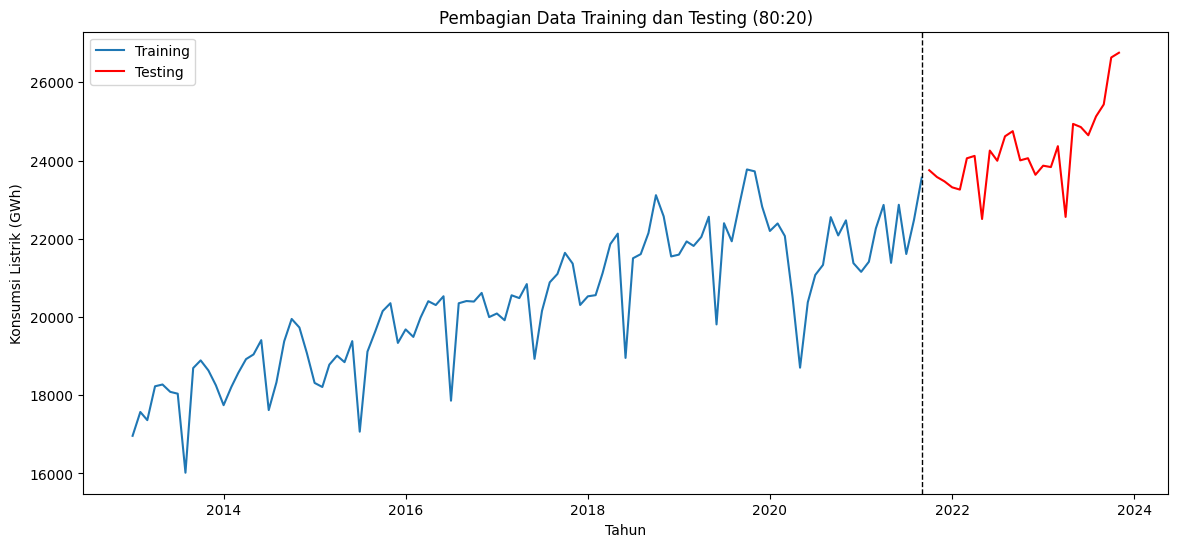

In [12]:
# Pembagian data: splitting window -> proporsi 80% training : 20% testing
train_ratio = 0.8

n_total = len(df_listrik)
n_test = round(n_total * (1 - train_ratio))

df_listrik_train = df_listrik.iloc[:-n_test].reset_index(drop=True)
df_listrik_test = df_listrik.iloc[-n_test:].reset_index(drop=True)

print(f'Total data           : {n_total} periode')
print(f'Proporsi training    : {train_ratio*100:.0f}%')
print(f'Proporsi testing     : {(1-train_ratio)*100:.0f}%')
print('Jumlah data training :', len(df_listrik_train))
print('Jumlah data testing  :', len(df_listrik_test))

plt.figure(figsize=(14,6))
plt.plot(df_listrik_train['date'], df_listrik_train['listrik'], label='Training')
plt.plot(df_listrik_test['date'], df_listrik_test['listrik'], label='Testing', color='red')
plt.axvline(df_listrik_train['date'].iloc[-1], color='black', linestyle='--', linewidth=1)
plt.title('Pembagian Data Training dan Testing (80:20)')
plt.xlabel('Tahun'); plt.ylabel('Konsumsi Listrik (GWh)'); plt.legend()
plt.show()

## **4. Visualisasi dan Identifikasi Pola Deret**

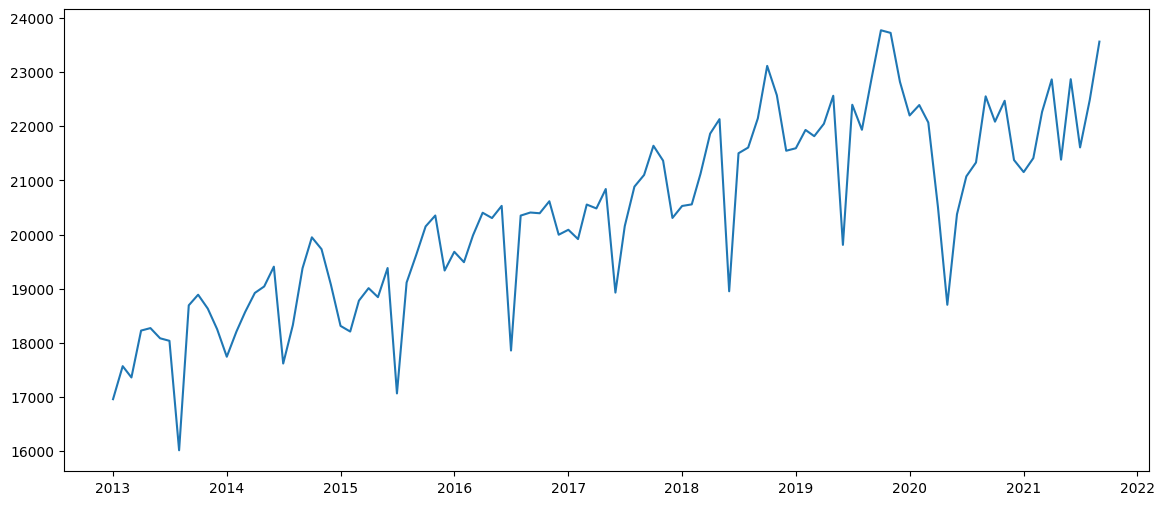

In [13]:
plt.figure(figsize=(14,6))
plt.plot(df_listrik_train['date'],df_listrik_train['listrik']); plt.show()

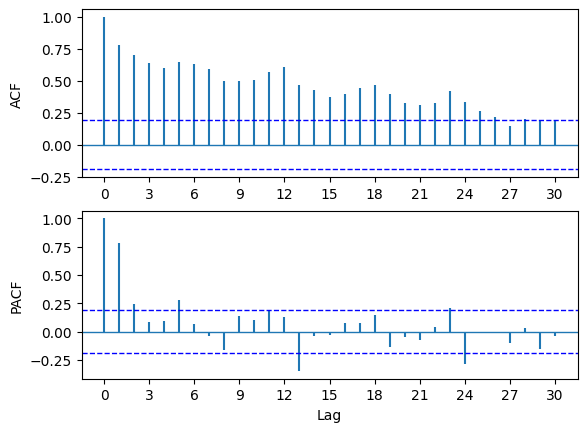

In [14]:
# membuat plot ACF dan PACF contoh dari data
acf_pacf_fig(df_listrik_train['listrik'], both=True, lag=30)

### Interpretasi eksplorasi
Berdasarkan plot deret waktu data training, konsumsi listrik menunjukkan pola yang berubah dari waktu ke waktu dan belum berfluktuasi di sekitar rata-rata yang konstan. Terlihat adanya kecenderungan perubahan level deret dari periode ke periode sehingga data diduga belum stasioner dalam nilai tengah. Plot ACF dan PACF pada data asli juga menunjukkan adanya autokorelasi pada beberapa lag. Oleh karena itu, perlu dilakukan pemeriksaan kestasioneran secara formal menggunakan uji Augmented Dickey-Fuller (ADF) sebelum menentukan orde differencing dan model ARIMA.


## **5. Uji Kestasioneran dalam Nilai Tengah**
Selain berdasarkan plot deret, kestasioneran suatu deret dapat diperiksa menggunakan uji statistik, salah satunya adalah uji ADF. Hipotesis yang digunakan dalam uji ADF adalah

$H_0$ menyatakan deret tidak stasioner

$H_1$ menyatakan deret stasioner.

Kriteria keputusan: Tolak $H_0$ jika p-value < 0.05

In [15]:
# uji unit-root Augmented Dickey Fuller
from statsmodels.tsa.stattools import adfuller

adfuller(df_listrik_train['listrik'])[1]

0.6952461702261316

In [16]:
p_adf_asli = adfuller(df_listrik_train['listrik'], autolag='AIC')[1]
if p_adf_asli < 0.05:
    print(f'Uji ADF data training menghasilkan p-value = {p_adf_asli:.6f} < 0.05; H0 ditolak sehingga deret dianggap stasioner dalam nilai tengah.')
else:
    print(f'Uji ADF data training menghasilkan p-value = {p_adf_asli:.6f} >= 0.05; H0 tidak ditolak sehingga differencing diperlukan.')

Uji ADF data training menghasilkan p-value = 0.695246 >= 0.05; H0 tidak ditolak sehingga differencing diperlukan.


### Interpretasi Uji ADF

Berdasarkan uji Augmented Dickey-Fuller (ADF) pada data training diperoleh p-value sebesar **0,695246**. Nilai tersebut lebih besar dari taraf signifikansi 5% (0,05), sehingga \(H_0\) tidak ditolak. Dengan demikian, terdapat bukti bahwa deret konsumsi listrik pada data training belum stasioner dalam nilai tengah. Oleh karena itu, diperlukan proses *differencing* untuk menghilangkan ketidakstasioneran sebelum dilakukan identifikasi model ARIMA.


## **6. Dekomposisi Deret Waktu**

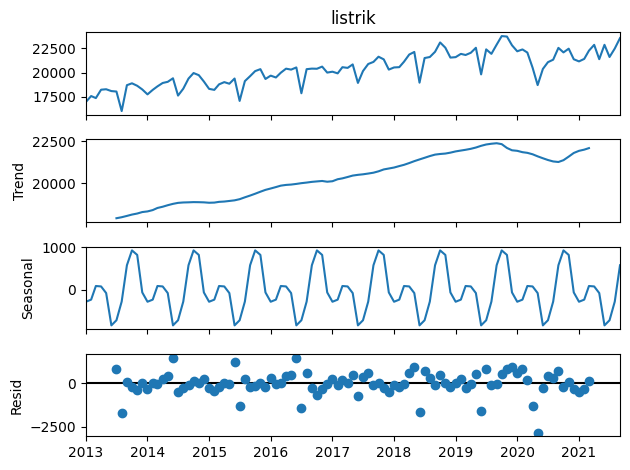

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose
df_listrik2=df_listrik_train.set_index('date')
result = seasonal_decompose(df_listrik2['listrik'], model='additive')
result.plot()
plt.show()

### Interpretasi Dekomposisi

Dekomposisi deret waktu dilakukan untuk memisahkan data konsumsi listrik menjadi komponen tren, musiman, dan residual. Hasil dekomposisi digunakan untuk membantu melihat perubahan pola konsumsi listrik sepanjang periode pengamatan. Komponen tren menunjukkan perubahan level konsumsi dari waktu ke waktu, sedangkan komponen musiman digunakan untuk melihat pola berulang pada periode tertentu. Informasi dari dekomposisi ini digunakan sebagai analisis eksploratif dan selanjutnya dikonfirmasi melalui pengujian kestasioneran serta analisis ACF dan PACF.


Selain dekomposisi, pola musiman dan pola antar tahun dapat ditelusuri lebih lanjut menggunakan boxplot.

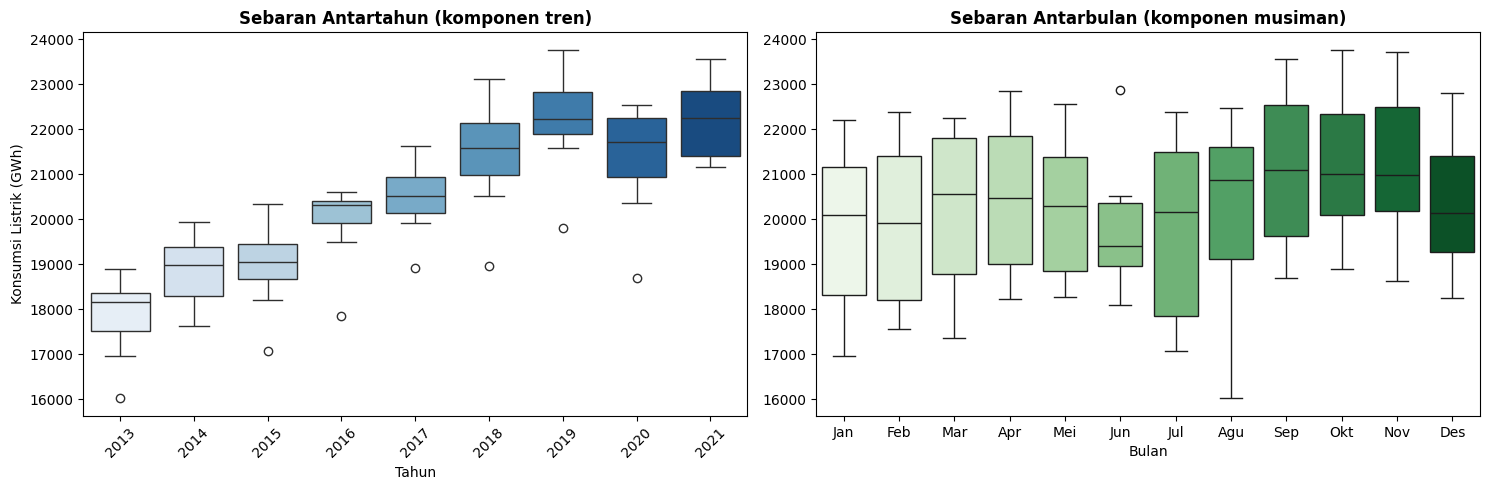

In [18]:
# menyiapkan data untuk boxplot antartahun dan antarbulan
pivot = df_listrik_train[['year', 'month', 'listrik']].rename(columns={'year': 'tahun', 'month': 'bulan'})
nama_bulan = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=pivot['tahun'], y=pivot['listrik'], ax=ax[0], palette='Blues')
ax[0].set_title('Sebaran Antartahun (komponen tren)', fontweight='bold')
ax[0].set_xlabel('Tahun'); ax[0].set_ylabel('Konsumsi Listrik (GWh)')
ax[0].tick_params(axis='x', rotation=45)

sns.boxplot(x=pivot['bulan'], y=pivot['listrik'], ax=ax[1], palette='Greens')
ax[1].set_title('Sebaran Antarbulan (komponen musiman)', fontweight='bold')
ax[1].set_xlabel('Bulan'); ax[1].set_ylabel('')
ax[1].set_xticklabels(nama_bulan)

plt.tight_layout(); plt.show()

### Interpretasi Boxplot

Boxplot antartahun digunakan untuk melihat perubahan tingkat konsumsi listrik dari tahun ke tahun, sedangkan boxplot antarbulan digunakan untuk melihat kemungkinan adanya pola musiman berdasarkan bulan. Perbedaan posisi median dan penyebaran data pada masing-masing kelompok memberikan gambaran mengenai perubahan level dan variasi konsumsi listrik. Hasil boxplot digunakan sebagai informasi pendukung dalam eksplorasi pola deret waktu dan tidak digunakan sebagai satu-satunya dasar dalam menentukan model ARIMA.


## **7. Uji Kestasioneran dalam Ragam (Box-Cox)**

**Jika dilihat berdasarkan plot deret, apakah deret sudah stasioner dalam ragam?**

Kestasioneran dalam ragam belum dapat ditentukan hanya berdasarkan plot deret. Oleh karena itu, kestasioneran ragam diperiksa lebih lanjut menggunakan transformasi Box-Cox. Parameter \(\lambda\) dan interval kepercayaannya digunakan untuk menentukan apakah transformasi diperlukan.


In [19]:
from scipy.stats import boxcox,  boxcox_llf
data,lambda_fit,ci=boxcox(df_listrik_train['listrik'], alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  1.5597717587174413
interval kepercayaan lambda: (-0.6160583219529697, 3.7996940754251343)


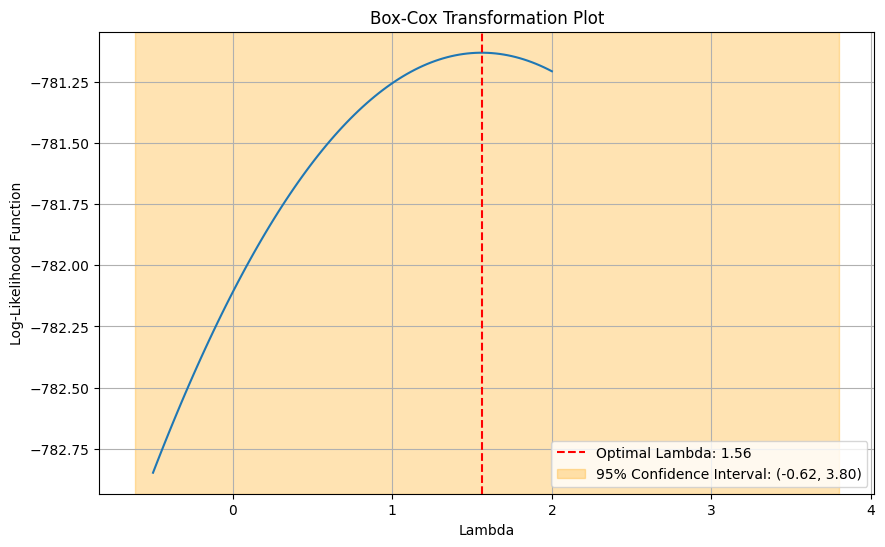

In [20]:
# Generate a range of lambda values
lambdas = np.linspace(-0.5, 2, 100)

# Calculate log-likelihood for each lambda
llf = [boxcox_llf(l, df_listrik_train['listrik']) for l in lambdas]

plt.figure(figsize=(10, 6))
plt.plot(lambdas, llf)
plt.axvline(lambda_fit, color='r', linestyle='--', label=f'Optimal Lambda: {lambda_fit:.2f}')
plt.axvspan(ci[0], ci[1], color='orange', alpha=0.3, label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})')
plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend(); plt.grid(True); plt.show()

### Interpretasi Box-Cox

Berdasarkan hasil transformasi Box-Cox diperoleh nilai parameter \(\lambda = 1,5598\) dengan interval kepercayaan 95% sebesar \((-0,6161; 3,7997)\). Nilai \(\lambda=1\) berada di dalam interval kepercayaan tersebut. Dengan demikian, tidak terdapat bukti yang cukup kuat bahwa transformasi Box-Cox diperlukan untuk menstabilkan ragam. Oleh karena itu, analisis dilanjutkan menggunakan data asli tanpa transformasi Box-Cox.


## **8. Penanganan Ketidakstasioneran**

Berdasarkan uji ADF, deret konsumsi listrik belum stasioner dalam nilai tengah. Sementara itu, hasil Box-Cox menunjukkan bahwa nilai \(\lambda=1\) masih berada dalam interval kepercayaan, sehingga tidak terdapat bukti kuat bahwa transformasi Box-Cox diperlukan. Oleh karena itu, penanganan ketidakstasioneran difokuskan pada nilai tengah melalui pembedaan (*differencing*).

### 8.1 Pembedaan Orde Pertama (Regular Differencing)

Pembedaan orde pertama dilakukan dengan menghitung

$$
Z_t=Y_t-Y_{t-1}
$$

yang bertujuan menghilangkan ketidakstasioneran dalam nilai tengah sehingga deret dapat digunakan untuk proses identifikasi model ARIMA.


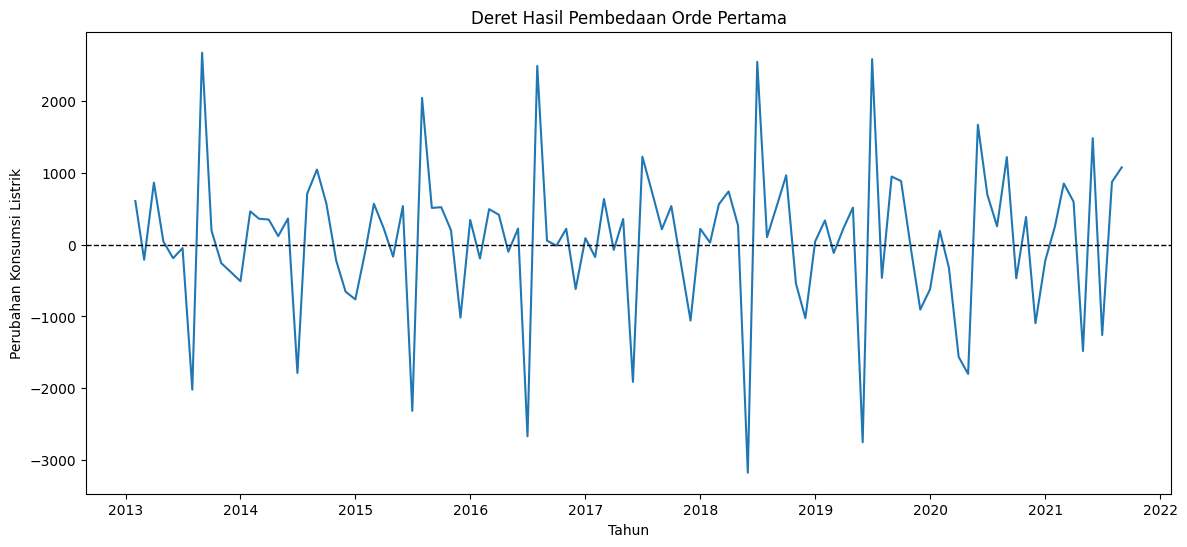

In [21]:
df_listrik_ts = df_listrik_train.set_index('date')['listrik']

diff1 = df_listrik_ts.diff().dropna()

plt.figure(figsize=(14,6))
plt.plot(diff1)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Deret Hasil Pembedaan Orde Pertama')
plt.xlabel('Tahun'); plt.ylabel('Perubahan Konsumsi Listrik')
plt.show()

In [24]:
p_adf_diff1 = adfuller(diff1, autolag='AIC')[1]
if p_adf_diff1 < 0.05:
    print(f'Setelah differencing orde pertama, p-value ADF = {p_adf_diff1:.6f} < 0.05; deret hasil differencing dianggap stasioner dan d=1 digunakan.')
else:
    print(f'Setelah differencing orde pertama, p-value ADF = {p_adf_diff1:.6f} >= 0.05; d=1 belum cukup menurut ADF sehingga orde differencing perlu ditinjau ulang.')

Setelah differencing orde pertama, p-value ADF = 0.003674 < 0.05; deret hasil differencing dianggap stasioner dan d=1 digunakan.


In [25]:
# Uji ADF setelah differencing
p_adf_diff1 = adfuller(diff1, autolag='AIC')[1]
p_adf_diff1

0.00367383851027492

### Interpretasi Setelah Differencing

Setelah dilakukan pembedaan orde pertama, diperoleh p-value uji ADF sebesar **0,003674**. Nilai tersebut lebih kecil dari taraf signifikansi 5%, sehingga \(H_0\) ditolak. Dengan demikian, deret hasil differencing orde pertama telah memenuhi indikasi stasioneritas dalam nilai tengah. Oleh karena itu, digunakan **orde differencing \(d=1\)** dalam model ARIMA.


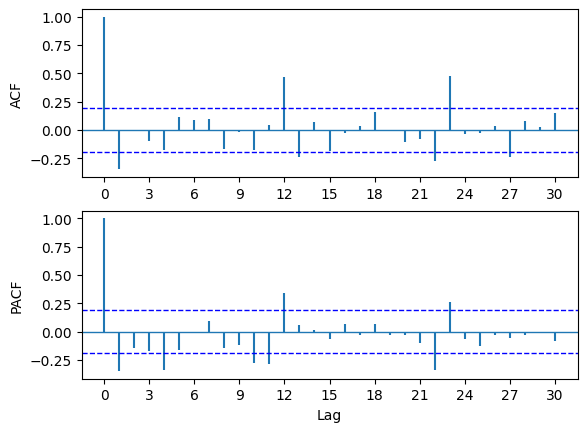

In [26]:
acf_pacf_fig(diff1, both=True, lag=30)

### Interpretasi ACF/PACF Setelah Differencing

Plot ACF dan PACF setelah differencing digunakan untuk mengidentifikasi kemungkinan orde \(p\) dan \(q\) pada model ARIMA. Pola ACF dan PACF memberikan informasi awal mengenai ketergantungan deret hasil differencing terhadap nilai masa lalu dan residual masa lalu. Hasil identifikasi ini selanjutnya digunakan bersama EACF untuk membentuk beberapa model kandidat. Penentuan model akhir tidak hanya didasarkan pada pola ACF dan PACF, tetapi juga mempertimbangkan AIC, BIC, signifikansi parameter, serta diagnostik residual melalui uji Ljung-Box.


## **9. Identifikasi Model ARIMA**
Setelah pada Bagian 8 diperoleh bahwa deret konsumsi listrik menjadi stasioner setelah pembedaan orde pertama ($d=1$), tahap selanjutnya dalam prosedur Box-Jenkins adalah **identifikasi model**, yaitu menduga orde *autoregressive* ($p$) dan *moving average* ($q$) berdasarkan pola plot ACF dan PACF pada data hasil pembedaan pertama (`diff1`) yang telah disajikan pada Bagian 8.2.

### 9.1 Plot ACF dan PACF pada Data Hasil Pembedaan Pertama

Setelah differencing orde pertama, deret telah memenuhi indikasi stasioneritas sehingga identifikasi difokuskan pada penentuan orde \(p\) dan \(q\). Pola ACF dan PACF digunakan sebagai informasi awal untuk menentukan wilayah kandidat model ARIMA. Karena pola tersebut tidak selalu memberikan satu model yang pasti, beberapa kombinasi orde \(p\) dan \(q\) kemudian dibandingkan menggunakan kriteria informasi dan diagnostik residual.


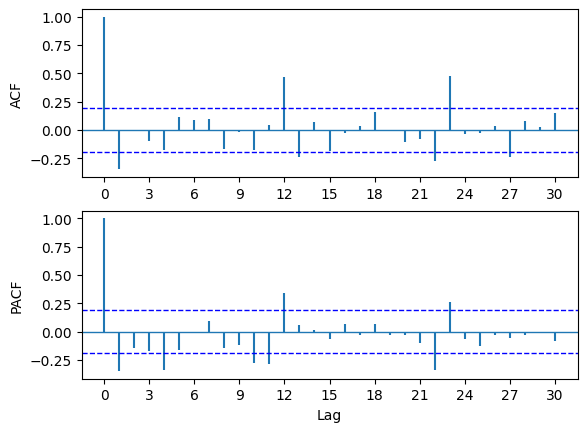

In [27]:
# ACF dan PACF pada deret hasil pembedaan orde pertama
acf_pacf_fig(diff1, both=True, lag=30)

### Interpretasi identifikasi model (otomatis)

### 9.2 Penentuan Orde Sementara Model

### 9.3 EACF untuk Menentukan Model Kandidat
EACF (*Extended Autocorrelation Function*) digunakan sebagai alat identifikasi tambahan pada deret yang telah stasioner. Perintah berikut menjalankan `TSA::eacf` di R, memasang paket `TSA` bila belum tersedia, dan menampilkan pola EACF untuk membantu membatasi kandidat orde ARMA pada deret hasil differencing. Model yang dipilih tetap harus lolos uji Ljung--Box; EACF bukan pengganti diagnostik residual.

In [44]:
# EACF dijalankan melalui R/TSA agar sesuai dengan prosedur tugas.
# Hasil EACF dipakai untuk menyusun wilayah kandidat p dan q; estimasi dan
# diagnostik final tetap dilakukan dengan ARIMA nonmusiman di Python.

eacf_csv = os.path.join(tempfile.gettempdir(), 'deret_diff1_untuk_eacf.csv')
pd.Series(diff1).dropna().to_csv(eacf_csv, index=False, header=False)

eacf_path_r = eacf_csv.replace('\\', '/')

eacf_r = f"""
if (!requireNamespace('TSA', quietly=TRUE)) install.packages('TSA', repos='https://cloud.r-project.org')
library(TSA)

z <- scan('{eacf_path_r}', quiet=TRUE)

cat('EACF pada deret hasil differencing orde pertama:\\n')
print(eacf(z, ar.max=12, ma.max=12))
"""

eacf_script = os.path.join(tempfile.gettempdir(), 'jalankan_eacf.R')

with open(eacf_script, 'w', encoding='utf-8') as f:
    f.write(eacf_r)

if shutil.which('Rscript'):
    hasil_eacf = subprocess.run(
        ['Rscript', eacf_script],
        capture_output=True,
        text=True
    )

    print(hasil_eacf.stdout)

    if hasil_eacf.returncode != 0:
        print('Pesan R/TSA:', hasil_eacf.stderr)

else:
    print(
        'Rscript belum tersedia pada lingkungan ini. '
        'Jalankan blok R berikut pada R/RStudio/Colab R '
        'untuk memperoleh tabel EACF:'
    )
    print(eacf_r)

EACF pada deret hasil differencing orde pertama:
AR/MA
   0 1 2 3 4 5 6 7 8 9 10 11 12
0  x o o o o o o o o o o  x  x 
1  x o o x o o o o o o o  x  o 
2  x o o o o o o o o o o  x  o 
3  x o x x o o o o o o o  x  x 
4  x o o x x o o o o o o  x  x 
5  o o o x o o o o o o o  x  o 
6  x o o x o o o o o o o  x  o 
7  x o x x o x x o o o o  x  o 
8  x x x o o o o o o o o  x  o 
9  x x o o x o o x o o o  x  o 
10 x o o x x o o x o o o  o  o 
11 x x x o o o o o o o x  o  o 
12 o o x o o o o o o o x  o  o 
$eacf
            [,1]         [,2]        [,3]        [,4]          [,5]
 [1,] -0.3492841 -0.004091133 -0.09729098 -0.18127604  0.1131670744
 [2,] -0.3655695  0.043539498 -0.03059963 -0.25953127  0.1135971519
 [3,] -0.4992368  0.096068185 -0.04644812 -0.19775569  0.1065136505
 [4,] -0.4074863 -0.177227116 -0.43114747 -0.38564165 -0.0240235651
 [5,] -0.4015329  0.154689484  0.15225548 -0.39595524 -0.2907479231
 [6,] -0.1596577  0.183860448  0.05659956 -0.39658823 -0.0535269177
 [7,]  0.257037

In [45]:
print('Interpretasi EACF: tabel EACF digunakan untuk mempersempit kandidat (p,q), bukan untuk menerima autokorelasi residual.')
print('Kandidat final akan diuji pada beberapa kombinasi p dan q nonmusiman; hanya model dengan seluruh p-value Ljung-Box > 0.05 yang dipertahankan.')

Interpretasi EACF: tabel EACF digunakan untuk mempersempit kandidat (p,q), bukan untuk menerima autokorelasi residual.
Kandidat final akan diuji pada beberapa kombinasi p dan q nonmusiman; hanya model dengan seluruh p-value Ljung-Box > 0.05 yang dipertahankan.


### Dasar Penentuan Kandidat

EACF digunakan sebagai informasi tambahan untuk mempersempit wilayah kandidat orde \(p\) dan \(q\) pada deret yang telah didifference. Berdasarkan wilayah tersebut, dilakukan estimasi terhadap kombinasi model ARIMA nonmusiman dengan \(d=1\). Sebanyak **36 kandidat model** dibandingkan menggunakan AIC, BIC, signifikansi parameter, serta uji Ljung-Box terhadap residual. Model yang memenuhi diagnostik residual kemudian dipertimbangkan berdasarkan kriteria informasi tersebut.


## **10. Pendugaan Parameter Model (Estimasi)**

Data *training* (`df_listrik_train`) telah dipisahkan sebelum pemeriksaan kestasioneran maupun identifikasi model. Kandidat model ARIMA diestimasi menggunakan data *training*. Forecasting pada data *testing* dilakukan setelah model dipilih dan digunakan sebagai evaluasi kemampuan ramalan.

### 10.1 Pendugaan Model Kandidat
Kandidat dibentuk dari wilayah orde yang diarahkan oleh EACF. Setiap kandidat ARIMA nonmusiman kemudian diestimasi dan diuji residualnya.


In [46]:
# Pendugaan kandidat ARIMA nonmusiman.
# EACF memberi petunjuk wilayah p dan q; pencarian berikut memeriksa wilayah
# tersebut secara eksplisit agar autokorelasi residual tidak dibiarkan.
d = 1
maks_pq = 12

kandidat_order = {(p, d, q): f'ARIMA({p},{d},{q})'
                  for p in range(maks_pq + 1)
                  for q in range(maks_pq + 1)
                  if not (p == 0 and q == 0)}

# ARIMA(0,1,0) tetap disertakan sebagai pembanding.
kandidat_order[(0, d, 0)] = 'ARIMA(0,1,0)'

hasil_kandidat = []
model_kandidat = {}

for order, nama in kandidat_order.items():
    try:
        model_fit = ARIMA(
            df_listrik_ts,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit()

        resid = model_fit.resid.iloc[
            model_fit.loglikelihood_burn:
        ].dropna()

        lag_maks = min(24, max(1, len(resid)//5))

        lags = sorted(
            set([6, 12, 18, 24]).intersection(
                range(1, lag_maks + 1)
            )
        )

        if not lags:
            lags = [lag_maks]

        lb = acorr_ljungbox(
            resid,
            lags=lags,
            return_df=True
        )

        pvals = model_fit.pvalues.drop(
            'sigma2',
            errors='ignore'
        )

        hasil_kandidat.append({
            'Model': nama,
            'order (p,d,q)': order,
            'AIC': model_fit.aic,
            'BIC': model_fit.bic,
            'Semua parameter signifikan (p<0.05)': bool(
                (pvals < 0.05).all()
            ),
            'Min p-value Ljung-Box': lb['lb_pvalue'].min(),
            'White noise (semua p>0.05)': bool(
                (lb['lb_pvalue'] > 0.05).all()
            )
        })

        model_kandidat[nama] = model_fit

    except Exception as exc:
        print(f'{nama} dilewati: {exc}')

tabel_kandidat = (
    pd.DataFrame(hasil_kandidat)
    .sort_values(
        ['White noise (semua p>0.05)', 'AIC', 'BIC'],
        ascending=[False, True, True]
    )
    .reset_index(drop=True)
)

display(tabel_kandidat)

,Model,"order (p,d,q)",AIC,BIC,Semua parameter signifikan (p<0.05),Min p-value Ljung-Box,White noise (semua p>0.05)
0,"ARIMA(11,1,12)","(11, 1, 12)",1478.916719,1539.177347,False,4.995381e-01,True
1,"ARIMA(10,1,12)","(10, 1, 12)",1487.264580,1545.014349,False,7.743569e-01,True
2,"ARIMA(1,1,12)","(1, 1, 12)",1488.165608,1523.317641,False,7.703316e-01,True
3,"ARIMA(5,1,12)","(5, 1, 12)",1489.543668,1534.739139,False,7.818008e-01,True
4,"ARIMA(2,1,12)","(2, 1, 12)",1490.164397,1527.827290,False,7.439491e-01,True
...,...,...,...,...,...,...,...
164,"ARIMA(0,1,1)","(0, 1, 1)",1690.213007,1695.462953,True,1.898810e-09,False
165,"ARIMA(2,1,0)","(2, 1, 0)",1699.613482,1707.488401,False,1.769641e-11,False
166,"ARIMA(1,1,0)","(1, 1, 0)",1715.377828,1720.647286,True,4.983793e-11,False
167,"ARIMA(0,1,0)","(0, 1, 0)",1726.637807,1729.272536,True,5.917926e-08,False


### Kriteria pemilihan model
Model dipilih dari kandidat yang memenuhi diagnostik residual white noise; AIC dan BIC digunakan untuk membandingkan model yang lolos.

### Kriteria Pemilihan Model

Model kandidat terlebih dahulu diperiksa berdasarkan diagnostik residual menggunakan uji Ljung-Box. Kandidat yang menghasilkan residual *white noise* dipertahankan. Selanjutnya, signifikansi parameter diperiksa sebagai informasi tambahan. Jika terdapat kandidat *white noise* dengan seluruh parameter signifikan, kandidat tersebut diprioritaskan. Jika tidak terdapat kandidat seperti itu, AIC dan BIC digunakan untuk memilih model dengan keseimbangan antara kecocokan model dan kompleksitas yang lebih baik.


In [47]:
# Model final wajib memenuhi white-noise residual. Di antara model yang lolos,
# parameter signifikan diprioritaskan, kemudian AIC dan BIC terkecil.
eligible = tabel_kandidat[tabel_kandidat['White noise (semua p>0.05)']].copy()
if len(eligible) == 0:
    raise RuntimeError('Tidak ada kandidat ARIMA nonmusiman yang menghasilkan residual white noise. Perlu memperluas orde p/q atau meninjau data; autokorelasi tidak boleh dibiarkan.')
eligible_sig = eligible[eligible['Semua parameter signifikan (p<0.05)']]
if len(eligible_sig) > 0:
    eligible = eligible_sig
    dasar_pemilihan = 'residual white noise, seluruh parameter signifikan, lalu AIC dan BIC terkecil'
else:
    dasar_pemilihan = 'residual white noise, lalu AIC dan BIC terkecil karena tidak semua kandidat white-noise memiliki seluruh parameter signifikan'
terpilih = eligible.sort_values(['AIC', 'BIC']).iloc[0]
nama_model_terpilih = terpilih['Model']
model_final = model_kandidat[nama_model_terpilih]
print('Model final:', nama_model_terpilih)
print('Dasar pemilihan:', dasar_pemilihan)
print(model_final.summary())

Model final: ARIMA(11,1,12)
Dasar pemilihan: residual white noise, lalu AIC dan BIC terkecil karena tidak semua kandidat white-noise memiliki seluruh parameter signifikan
                               SARIMAX Results                                
Dep. Variable:                listrik   No. Observations:                  105
Model:               ARIMA(11, 1, 12)   Log Likelihood                -715.458
Date:                Wed, 23 Sep 2026   AIC                           1478.917
Time:                        14:04:39   BIC                           1539.177
Sample:                    01-01-2013   HQIC                          1503.228
                         - 09-01-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.3693      0.258     -5

In [48]:
p, d, q = model_final.model.order
params = model_final.params
terms = []
for i in range(1, p + 1):
    terms.append(f'{params[f"ar.L{i}"]:+.4f}·Z(t-{i})')
terms.append('+e(t)')
for i in range(1, q + 1):
    terms.append(f'{params[f"ma.L{i}"]:+.4f}·e(t-{i})')
persamaan = 'Z(t) = ' + ' '.join(terms)
if persamaan.startswith('Z(t) = +'): persamaan = 'Z(t) = ' + persamaan[len('Z(t) = +'):]
print(f'Model terpilih: ARIMA({p},{d},{q}) = ARMA({p},{q}) pada deret yang telah didifference {d} kali.')
print('Persamaan model:', persamaan)

Model terpilih: ARIMA(11,1,12) = ARMA(11,12) pada deret yang telah didifference 1 kali.
Persamaan model: Z(t) = -1.3693·Z(t-1) -1.2679·Z(t-2) -1.1581·Z(t-3) -1.0760·Z(t-4) -0.9256·Z(t-5) -0.8163·Z(t-6) -0.6971·Z(t-7) -0.7459·Z(t-8) -0.7615·Z(t-9) -1.0317·Z(t-10) -0.7999·Z(t-11) +e(t) +0.9368·e(t-1) +0.7466·e(t-2) +0.6144·e(t-3) +0.3595·e(t-4) +0.0267·e(t-5) -0.0226·e(t-6) -0.0432·e(t-7) +0.1219·e(t-8) +0.1007·e(t-9) +0.5249·e(t-10) +0.1264·e(t-11) -0.2638·e(t-12)


### Interpretasi Model Terpilih

Berdasarkan hasil perbandingan kandidat, model yang terpilih adalah **ARIMA(11,1,12)**, yaitu model dengan komponen autoregressive (AR) orde 11, differencing orde 1, dan moving average (MA) orde 12. Model ini merupakan model ARMA(11,12) pada deret yang telah dilakukan differencing satu kali. Pemilihan model didasarkan pada hasil perbandingan kandidat ARIMA dengan wilayah orde \(p\) dan \(q\) hingga 12, dengan mempertimbangkan kriteria informasi serta hasil diagnostik residual.

Model ARIMA(11,1,12) menunjukkan bahwa nilai deret setelah differencing dipengaruhi oleh nilai masa lalu hingga lag ke-11 serta error masa lalu hingga lag ke-12. Hasil uji diagnostik residual selanjutnya digunakan untuk memastikan bahwa residual model telah memenuhi asumsi *white noise*. Selain itu, nilai AIC dan BIC digunakan sebagai kriteria dalam membandingkan kualitas model dengan kandidat ARIMA lainnya.

Dalam interpretasi parameter, perlu diperhatikan bahwa tidak seluruh koefisien AR dan MA harus signifikan secara individual pada taraf 5%. Oleh karena itu, signifikansi masing-masing parameter tetap dicantumkan sebagai bagian dari evaluasi model, sedangkan pemilihan model secara keseluruhan didasarkan pada kombinasi kriteria informasi dan diagnostik residual.


## **11. Diagnostik Model (Uji Kelayakan)**

Diagnostik dilakukan untuk memeriksa apakah residual model sudah tidak mengandung autokorelasi yang signifikan. Pemeriksaan meliputi plot residual, ACF residual, Q-Q plot, uji Ljung-Box, uji Jarque-Bera, dan pemeriksaan overfitting.


### 11.1 Pengecekan Sisaan: Plot ACF Sisaan, Plot Sisaan, dan Plot QQ

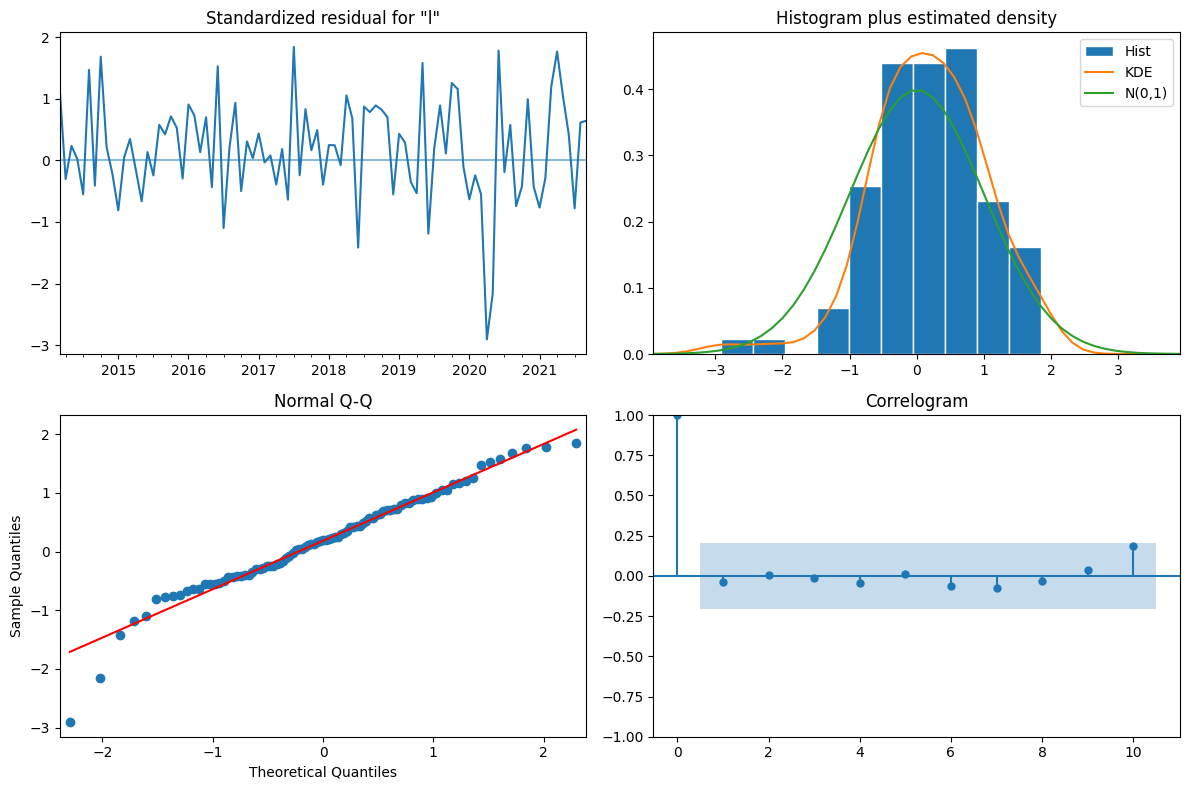

In [49]:
model_final.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

### Interpretasi Plot Residual

Plot diagnostik digunakan untuk memeriksa pola residual model ARIMA(3,1,5). Pemeriksaan meliputi residual terhadap waktu, distribusi residual, ACF residual, dan Q-Q plot. Secara umum, residual diharapkan tidak menunjukkan pola sistematis dan autokorelasi yang kuat. Hasil pemeriksaan formal menggunakan uji Ljung-Box digunakan sebagai dasar utama untuk menentukan apakah residual telah memenuhi karakteristik *white noise*.


### 11.2 Uji Formal: Ljung-Box (White Noise) dan Uji Normalitas

In [50]:
resid_valid = model_final.resid.iloc[model_final.loglikelihood_burn:].dropna()
lag_maks = min(24, max(1, len(resid_valid)//5))
lags_uji = sorted(set([6, 12, 18, 24]).intersection(range(1, lag_maks + 1))) or [lag_maks]
uji_ljungbox = acorr_ljungbox(resid_valid, lags=lags_uji, return_df=True)
display(uji_ljungbox)
jb_stat, jb_pvalue = jarque_bera(resid_valid)
print(f'Uji Jarque-Bera: statistik = {jb_stat:.4f}, p-value = {jb_pvalue:.4f}')

,lb_stat,lb_pvalue
6,1.104736,0.981329
12,11.345809,0.499538
18,16.557862,0.553674


Uji Jarque-Bera: statistik = 8.3357, p-value = 0.0155


In [51]:
print('Interpretasi uji Ljung-Box:')
for lag, row in uji_ljungbox.iterrows():
    keputusan = 'gagal menolak H0 (tidak ada autokorelasi signifikan)' if row['lb_pvalue'] > 0.05 else 'menolak H0 (masih ada autokorelasi signifikan)'
    print(f'Lag {int(lag)}: p-value = {row["lb_pvalue"]:.6f} -> {keputusan}.')
lb_pass = bool((uji_ljungbox['lb_pvalue'] > 0.05).all())
print('Kesimpulan diagnostik:', 'residual white noise; model memenuhi syarat autokorelasi.' if lb_pass else 'residual belum white noise; model tidak boleh digunakan dan perlu perluasan kandidat p/q.')
print(f'Jarque-Bera p-value = {jb_pvalue:.6f}:', 'tidak ada bukti kuat penyimpangan normalitas.' if jb_pvalue > 0.05 else 'terdapat penyimpangan dari normalitas; ini dicatat sebagai karakteristik residual, bukan alasan untuk membiarkan autokorelasi.')

Interpretasi uji Ljung-Box:
Lag 6: p-value = 0.981329 -> gagal menolak H0 (tidak ada autokorelasi signifikan).
Lag 12: p-value = 0.499538 -> gagal menolak H0 (tidak ada autokorelasi signifikan).
Lag 18: p-value = 0.553674 -> gagal menolak H0 (tidak ada autokorelasi signifikan).
Kesimpulan diagnostik: residual white noise; model memenuhi syarat autokorelasi.
Jarque-Bera p-value = 0.015486: terdapat penyimpangan dari normalitas; ini dicatat sebagai karakteristik residual, bukan alasan untuk membiarkan autokorelasi.


### 11.3 Uji *Overfitting*

Uji overfitting dilakukan dengan menambah satu orde AR atau satu orde MA dari model tentatif. Jika penambahan parameter tidak signifikan dan model yang lebih kompleks tidak memberikan perbaikan AIC/BIC yang berarti, model yang lebih sederhana dipertahankan.


In [52]:
# Pemeriksaan kompleksitas tambahan di sekitar model final
p, d, q = model_final.model.order

model_final_row = tabel_kandidat[
    tabel_kandidat['Model'] == nama_model_terpilih
].copy()

model_lebih_kompleks = tabel_kandidat[
    tabel_kandidat['Model'] == f'ARIMA({p+1},{d},{q})'
].copy()

tabel_overfit = pd.concat(
    [model_final_row, model_lebih_kompleks],
    ignore_index=True
).drop_duplicates(subset=['Model'])

display(tabel_overfit)

print(f'AIC model final      : {model_final.aic:.3f}')
print(f'BIC model final      : {model_final.bic:.3f}')

if len(model_lebih_kompleks) > 0:
    print(f"AIC model lebih kompleks : {model_lebih_kompleks.iloc[0]['AIC']:.3f}")
    print(f"BIC model lebih kompleks : {model_lebih_kompleks.iloc[0]['BIC']:.3f}")

,Model,"order (p,d,q)",AIC,BIC,Semua parameter signifikan (p<0.05),Min p-value Ljung-Box,White noise (semua p>0.05)
0,"ARIMA(11,1,12)","(11, 1, 12)",1478.916719,1539.177347,False,0.499538,True
1,"ARIMA(12,1,12)","(12, 1, 12)",1486.140649,1548.912137,False,0.009671,False


AIC model final      : 1478.917
BIC model final      : 1539.177
AIC model lebih kompleks : 1486.141
BIC model lebih kompleks : 1548.912


## **12. Kesimpulan Model**


In [53]:
p_asli = adfuller(df_listrik_ts, autolag='AIC')[1]
p_diff = p_adf_diff1
p, d, q = model_final.model.order
lb_pass = bool((uji_ljungbox['lb_pvalue'] > 0.05).all())
print(f'1. ADF data asli: p-value = {p_asli:.6f}.')
print(f'2. ADF setelah differencing: p-value = {p_diff:.6f}; orde differencing yang digunakan d = {d}.')
print(f'3. EACF digunakan untuk mengarahkan kandidat ARMA, kemudian {len(tabel_kandidat)} kandidat ARIMA nonmusiman dibandingkan.')
print(f'4. Model final: {nama_model_terpilih}; AIC = {model_final.aic:.3f}; BIC = {model_final.bic:.3f}.')
print(f'5. Ljung-Box: {"semua lag yang diuji tidak signifikan sehingga residual white noise" if lb_pass else "masih terdapat autokorelasi signifikan sehingga model harus ditinjau ulang"}.')
print(f'6. Kesimpulan: {nama_model_terpilih} digunakan karena memenuhi diagnostik residual dan memiliki kriteria informasi terbaik di antara kandidat yang lolos.')
print('   Dalam konteks deret hasil differencing, model ini ekuivalen dengan ARMA(p,q); pada deret asli ditulis sebagai ARIMA(p,d,q).')

1. ADF data asli: p-value = 0.695246.
2. ADF setelah differencing: p-value = 0.003674; orde differencing yang digunakan d = 1.
3. EACF digunakan untuk mengarahkan kandidat ARMA, kemudian 169 kandidat ARIMA nonmusiman dibandingkan.
4. Model final: ARIMA(11,1,12); AIC = 1478.917; BIC = 1539.177.
5. Ljung-Box: semua lag yang diuji tidak signifikan sehingga residual white noise.
6. Kesimpulan: ARIMA(11,1,12) digunakan karena memenuhi diagnostik residual dan memiliki kriteria informasi terbaik di antara kandidat yang lolos.
   Dalam konteks deret hasil differencing, model ini ekuivalen dengan ARMA(p,q); pada deret asli ditulis sebagai ARIMA(p,d,q).


## **13. Forecasting Menggunakan Model ARIMA**
Forecast dilakukan menggunakan model final yang telah lolos uji white noise pada residual.

### 13.1 Validasi Model pada Data Testing

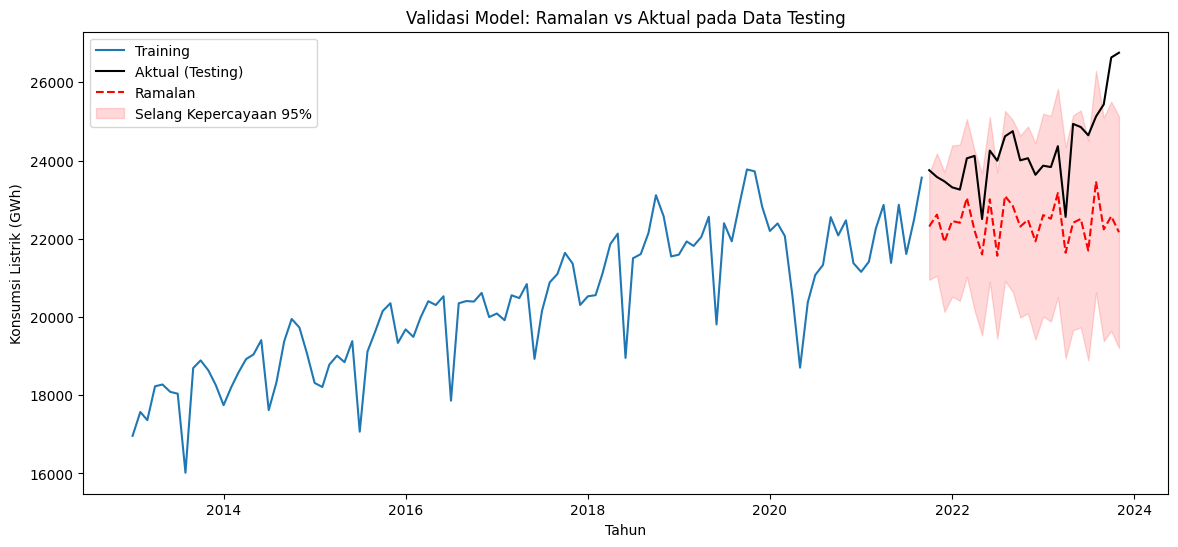

In [54]:
# Membentuk deret testing (bertipe Series berindeks tanggal) dari df_listrik_test
test_ts = df_listrik_test.set_index('date')['listrik']

# Peramalan sepanjang periode data testing
ramalan_test = model_final.get_forecast(steps=n_test)
ramalan_mean = ramalan_test.predicted_mean
ramalan_ci = ramalan_test.conf_int(alpha=0.05)

plt.figure(figsize=(14,6))
plt.plot(df_listrik_ts.index, df_listrik_ts, label='Training')
plt.plot(test_ts.index, test_ts, label='Aktual (Testing)', color='black')
plt.plot(test_ts.index, ramalan_mean.values, label='Ramalan', color='red', linestyle='--')
plt.fill_between(test_ts.index, ramalan_ci.iloc[:,0].values, ramalan_ci.iloc[:,1].values, color='red', alpha=0.15, label='Selang Kepercayaan 95%')
plt.title('Validasi Model: Ramalan vs Aktual pada Data Testing')
plt.xlabel('Tahun'); plt.ylabel('Konsumsi Listrik (GWh)'); plt.legend()
plt.show()

In [56]:
# Evaluasi akurasi ramalan pada data testing
import numpy as np

rmse = np.sqrt(np.mean((test_ts.values - ramalan_mean.values)**2))
mape = np.mean(np.abs((test_ts.values - ramalan_mean.values) / test_ts.values)) * 100

print(f'RMSE : {rmse:.3f}')
print(f'MAPE : {mape:.2f}%')

RMSE : 2063.615
MAPE : 7.43%


In [57]:
print(f'RMSE = {rmse:.3f}')
print(f'MAPE = {mape:.2f}%')
print('Semakin kecil RMSE dan MAPE, semakin kecil kesalahan ramalan pada data testing.')
print('Evaluasi ini digunakan sebagai informasi tambahan untuk menilai kemampuan forecasting model pada 12 observasi terakhir.')


RMSE = 2063.615
MAPE = 7.43%
Semakin kecil RMSE dan MAPE, semakin kecil kesalahan ramalan pada data testing.
Evaluasi ini digunakan sebagai informasi tambahan untuk menilai kemampuan forecasting model pada 12 observasi terakhir.


In [41]:
print(f'Interpretasi forecast: RMSE testing = {rmse:.3f} dan MAPE = {mape:.2f}%.')
print('Nilai MAPE yang lebih kecil menunjukkan ramalan lebih dekat dengan aktual pada data testing.')
print(f'Ramalan periode mendatang menggunakan {nama_model_terpilih} dan interval kepercayaan 95% yang dihitung dari model final.')

Interpretasi forecast: RMSE testing = 1953.860 dan MAPE = 6.82%.
Nilai MAPE yang lebih kecil menunjukkan ramalan lebih dekat dengan aktual pada data testing.
Ramalan periode mendatang menggunakan ARIMA(3,1,5) dan interval kepercayaan 95% yang dihitung dari model final.


### 13.2 Peramalan Periode Mendatang

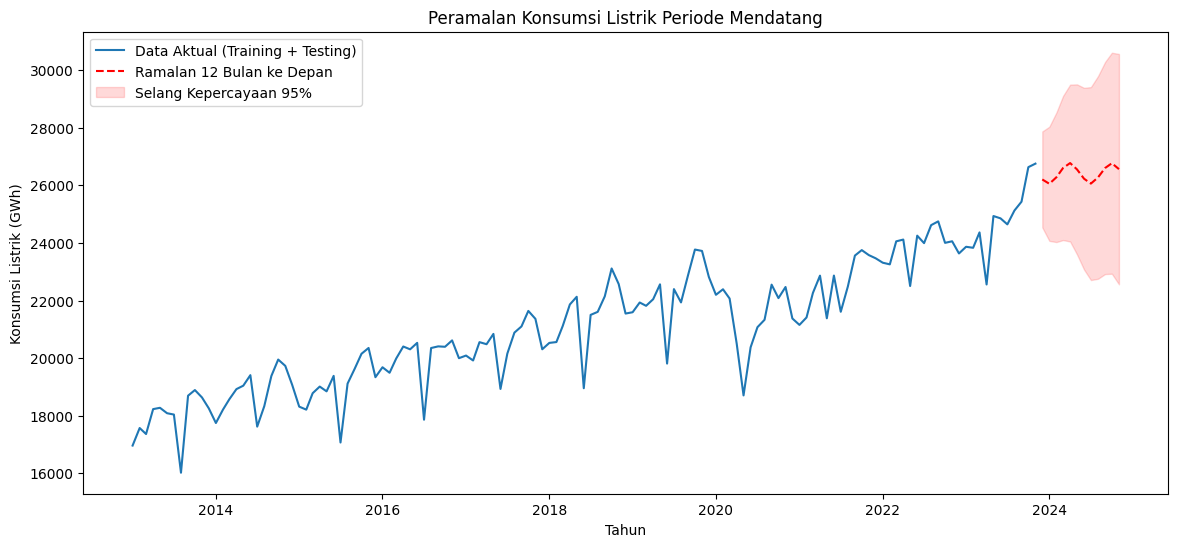

,predicted_mean
2023-12-01,26206.434659
2024-01-01,26055.666895
2024-02-01,26282.554585
2024-03-01,26603.595959
2024-04-01,26775.596372
2024-05-01,26556.656177
2024-06-01,26231.872470
2024-07-01,26062.294920
2024-08-01,26274.222767
2024-09-01,26601.861324


In [42]:
# Untuk peramalan periode mendatang, model diduga ulang menggunakan SELURUH data
# (data training + testing digabung kembali) agar informasi terbaru ikut digunakan
n_forecast = 12  # jumlah bulan ke depan yang diramalkan

df_listrik_ts_full = df_listrik.set_index('date')['listrik']  # seluruh data (df_listrik_train + df_listrik_test)
model_full = ARIMA(df_listrik_ts_full, order=model_final.model.order).fit()

ramalan_depan = model_full.get_forecast(steps=n_forecast)
ramalan_depan_mean = ramalan_depan.predicted_mean
ramalan_depan_ci = ramalan_depan.conf_int(alpha=0.05)

plt.figure(figsize=(14,6))
plt.plot(df_listrik_ts_full.index, df_listrik_ts_full, label='Data Aktual (Training + Testing)')
plt.plot(ramalan_depan_mean.index, ramalan_depan_mean, label=f'Ramalan {n_forecast} Bulan ke Depan', color='red', linestyle='--')
plt.fill_between(ramalan_depan_mean.index, ramalan_depan_ci.iloc[:,0], ramalan_depan_ci.iloc[:,1], color='red', alpha=0.15, label='Selang Kepercayaan 95%')
plt.title('Peramalan Konsumsi Listrik Periode Mendatang')
plt.xlabel('Tahun'); plt.ylabel('Konsumsi Listrik (GWh)'); plt.legend()
plt.show()

ramalan_depan_mean